In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report , confusion_matrix , ConfusionMatrixDisplay, accuracy_score
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
import os
import joblib
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [28]:
X_train = np.load(r'..\data\features\train_X.npy')
y_train = np.load(r'..\data\features\train_y.npy')
X_test  = np.load(r'..\data\features\test_X.npy')
y_test  = np.load(r'..\data\features\test_y.npy')

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [30]:
joblib.dump(scaler, '../data/features/scaler.pkl')

['../data/features/scaler.pkl']

In [31]:
print(f"Features Shape: {X_train.shape}")
print(f"Labels Shape: {y_train.shape}")
print(f"Data Type: {X_train.dtype}")
print(f"First 2 rows of features:\n{X_train[:2]}")
print(f"Unique Labels: {np.unique(y_train)}")

Features Shape: (28709, 1764)
Labels Shape: (28709,)
Data Type: float32
First 2 rows of features:
[[ 0.21853073  0.9737559   1.6172316  ... -0.8639742  -0.13258345
   0.22216286]
 [ 0.610603   -0.35807484  1.271959   ... -0.883876   -0.99965745
  -1.1078066 ]]
Unique Labels: [0 1 2 3 4 5 6]


In [32]:
input_dim = X_train.shape[1] 

model = Sequential([
    Dense(512, activation='relu', input_shape=(input_dim,)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 512)            │       903,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,071,879 (4.09 MB)

 Trainable params: 1,070,343 (4.08 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [33]:
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.15,
    stratify=y_train,   # guarantees all 7 classes in val
    random_state=42
)

history = model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),  # explicit, not a split
    callbacks=callbacks
)

Epoch 1/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3609 - loss: 1.7194 - val_accuracy: 0.4432 - val_loss: 1.4443 - learning_rate: 0.0010
Epoch 2/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4381 - loss: 1.4497 - val_accuracy: 0.4681 - val_loss: 1.3789 - learning_rate: 0.0010
Epoch 3/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4805 - loss: 1.3533 - val_accuracy: 0.4848 - val_loss: 1.3500 - learning_rate: 0.0010
Epoch 4/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5048 - loss: 1.2908 - val_accuracy: 0.4887 - val_loss: 1.3347 - learning_rate: 0.0010
Epoch 5/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5240 - loss: 1.2371 - val_accuracy: 0.4964 - val_loss: 1.3421 - learning_rate: 0.0010
Epoch 6/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5652 - loss: 1.1365 - val_accuracy: 0.5052 - val_loss: 1.3243 - learning_rate: 5.0000e-04
Epoch 7/100
382/382 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5905 - loss

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

       angry       0.34      0.28      0.31       958
     disgust       0.33      0.03      0.05       111
        fear       0.32      0.11      0.16      1024
       happy       0.61      0.77      0.68      1774
     neutral       0.38      0.48      0.43      1233
         sad       0.31      0.36      0.33      1247
    surprise       0.59      0.56      0.57       831

    accuracy                           0.45      7178
   macro avg       0.41      0.37      0.36      7178
weighted avg       0.44      0.45      0.43      7178



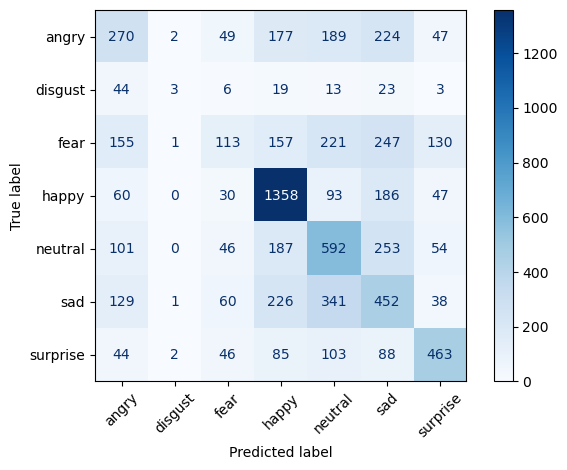

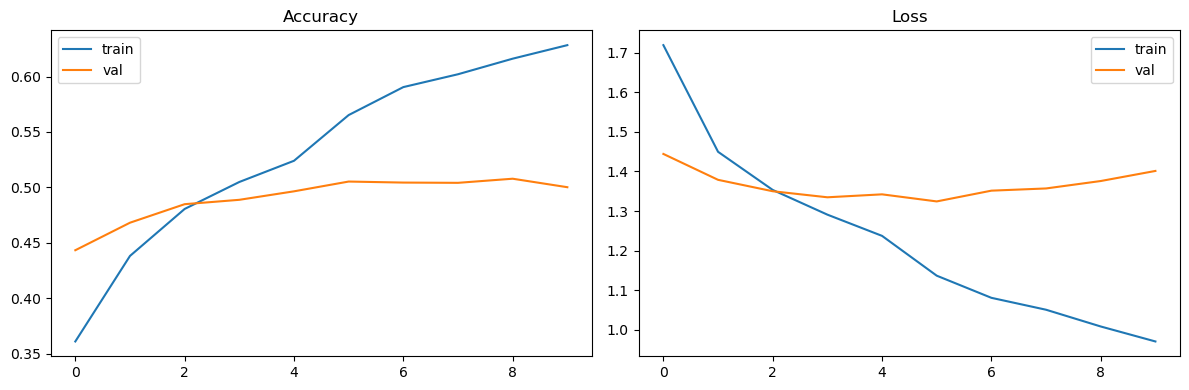

In [35]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# ── Accuracy on test set ──────────────────────────────────────────────────────
y_pred = model.predict(X_test).argmax(axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

# ── Confusion matrix ─────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=class_names,
    xticks_rotation=45,
    cmap='Blues'
)
plt.tight_layout()
plt.show()

# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
os.makedirs('../data/models', exist_ok=True)
model.save('../data/models/mlp_model.keras')